Imports

In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pathlib
import sys

project_root = pathlib.Path().resolve().parents[3]
sys.path.append(str(project_root))

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.circuit.library import efficient_su2
from qiskit.circuit import ParameterVector

from KnapsackHamiltonian import buildKnapsackHamiltonian
from AnsatzPruning.MomentumBuilder import MomentumBuilder
from AnsatzPruning.MomentumMonteCarlo import momentum_monte_carlo
from AnsatzPruning.Utilities import cost_func

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

print("Imports successful.")


Imports successful.


Define the Knapsack Probelm

In [5]:
values = [6, 10, 12]
weights = [1, 2, 3]
W = 3
P = 20.0

H = buildKnapsackHamiltonian(values, weights, W, P)
observables = [*H.paulis, H]

n = len(values)
print(f"{n}-qubit knapsack Hamiltonian loaded.")


3-qubit knapsack Hamiltonian loaded.


Energy Evaluation

In [6]:
def evaluate_energy(params, circuit, observables):
    est = Estimator()
    cost = cost_func(params, circuit, observables, est)
    return cost[-1]


EfficientSU2 Benchmarking

In [7]:
def benchmark_efficient_su2(H, observables, n):

    circuit = QuantumCircuit(n)
    su2 = efficient_su2(n, reps=2)
    circuit = circuit.compose(su2)

    num_params = len(circuit.parameters)
    params = np.random.random(num_params)

    start = time.time()
    energy = evaluate_energy(params, circuit, observables)
    end = time.time()

    return energy, num_params, end - start

Momentum Builder Benchmarking

In [8]:
def benchmark_momentum_builder(H, observables, n):

    estimator = Estimator()
    base_circuit = QuantumCircuit(n)
    ansatz = QuantumCircuit(n)

    params = []
    inds = []
    theta = ParameterVector("theta", n)

    for i in range(n):
        ansatz.rx(theta[i], i)
        params.append(1)
        inds.append(i)

    start = time.time()
    final_circuit = MomentumBuilder(
        params,
        inds,
        ansatz,
        base_circuit,
        observables,
        estimator,
        beta1=0.9,
        beta2=0.99,
        iters=2
    )
    end = time.time()

    num_params = len(final_circuit.parameters)
    rand_params = np.random.random(num_params)

    energy = evaluate_energy(rand_params, final_circuit, observables)

    return energy, num_params, end - start

Momentum MonteCarlo Benchmarking

In [9]:
def benchmark_momentum_montecarlo(H, observables, n):

    estimator = Estimator()
    base_circuit = QuantumCircuit(n)
    ansatz = QuantumCircuit(n)

    params = []
    inds = []
    theta = ParameterVector("theta", n)

    for i in range(n):
        ansatz.rx(theta[i], i)
        params.append(1)
        inds.append(i)

    start = time.time()

    final_circuit, final_params = momentum_monte_carlo(
        params,
        inds,
        ansatz,
        base_circuit,
        H,                     # pass H here
        estimator,
        beta1=0.9,
        beta2=0.99,
        iters=2,
        optimization_runs=50
    )

    end = time.time()

    energy = evaluate_energy(final_params, final_circuit, observables)

    return energy, len(final_params), end - start

Running Multiple Trials

In [10]:
from KanpsackProblems import KnapsackProblemSet

TRIALS = 10
results = []

problem_set = KnapsackProblemSet()
problems = problem_set.createProblemSets()

print("="*70)
print("RUNNING BENCHMARKS")
print("="*70)

for problem_index, (H, expected) in enumerate(problems):

    n = H.num_qubits
    observables = [*H.paulis, H]

    print(f"\nProblem {problem_index+1} | Qubits: {n}")
    print("-"*50)

    for trial in range(TRIALS):

        print(f"Trial {trial+1}/{TRIALS}", end=" | ")

        # EfficientSU2 (always safe)
        e, p, t = benchmark_efficient_su2(H, observables, n)
        results.append({
            "problem_id": problem_index+1,
            "ansatz_type": "EfficientSU2",
            "energy": e,
            "params": p,
            "time": t
        })

        # Only run Momentum methods if n >= 2
        if n >= 2:

            e, p, t = benchmark_momentum_builder(H, observables, n)
            results.append({
                "problem_id": problem_index+1,
                "ansatz_type": "Momentum",
                "energy": e,
                "params": p,
                "time": t
            })

            e, p, t = benchmark_momentum_montecarlo(H, observables, n)
            results.append({
                "problem_id": problem_index+1,
                "ansatz_type": "MomentumMonteCarlo",
                "energy": e,
                "params": p,
                "time": t
            })

        print("✓")

df = pd.DataFrame(results)

print("\n" + "="*70)
print(f"Completed {len(df)} total runs")
print("="*70)

df.head()

RUNNING BENCHMARKS

Problem 1 | Qubits: 1
--------------------------------------------------
Trial 1/10 | ✓
Trial 2/10 | ✓
Trial 3/10 | ✓
Trial 4/10 | ✓
Trial 5/10 | ✓
Trial 6/10 | ✓
Trial 7/10 | ✓
Trial 8/10 | ✓
Trial 9/10 | ✓
Trial 10/10 | ✓

Problem 2 | Qubits: 1
--------------------------------------------------
Trial 1/10 | ✓
Trial 2/10 | ✓
Trial 3/10 | ✓
Trial 4/10 | ✓
Trial 5/10 | ✓
Trial 6/10 | ✓
Trial 7/10 | ✓
Trial 8/10 | ✓
Trial 9/10 | ✓
Trial 10/10 | ✓

Problem 3 | Qubits: 2
--------------------------------------------------
Trial 1/10 | Energy after MomentumBuilder:  66.546766141902
Energy after MomentumBuilder and Monte Carlo:  14.228689746249408
✓
Trial 2/10 | Energy after MomentumBuilder:  66.546766141902
Energy after MomentumBuilder and Monte Carlo:  12.501692582824525
✓
Trial 3/10 | Energy after MomentumBuilder:  66.546766141902
Energy after MomentumBuilder and Monte Carlo:  3.963400286459767
✓
Trial 4/10 | Energy after MomentumBuilder:  66.546766141902
Energy after M

,problem_id,ansatz_type,energy,params,time
0,1,EfficientSU2,180.362231,6,0.008042
1,1,EfficientSU2,311.618360,6,0.002921
2,1,EfficientSU2,299.197388,6,0.003042
3,1,EfficientSU2,194.470644,6,0.003003
4,1,EfficientSU2,391.988947,6,0.003006


Summary Statistics

In [11]:
summary = df.groupby("ansatz_type").agg({
    "energy":["mean","std","min","max"],
    "time":["mean","std"],
    "params":["mean","std"]
})

summary


energy                                        time  \
                          mean        std        min         max      mean   
ansatz_type                                                                  
EfficientSU2        186.968721  91.245547  68.810612  472.156131  0.035976   
Momentum            165.895065  65.089732  50.130785  373.112391  0.398297   
MomentumMonteCarlo   31.008701  29.382946 -12.850320  136.026116  1.512467   

                             params             
                         std   mean        std  
ansatz_type                                     
EfficientSU2        0.060388   21.5  11.394382  
Momentum            0.538634    8.1   1.648385  
MomentumMonteCarlo  1.488114    8.1   1.648385

Main Comparision Plots

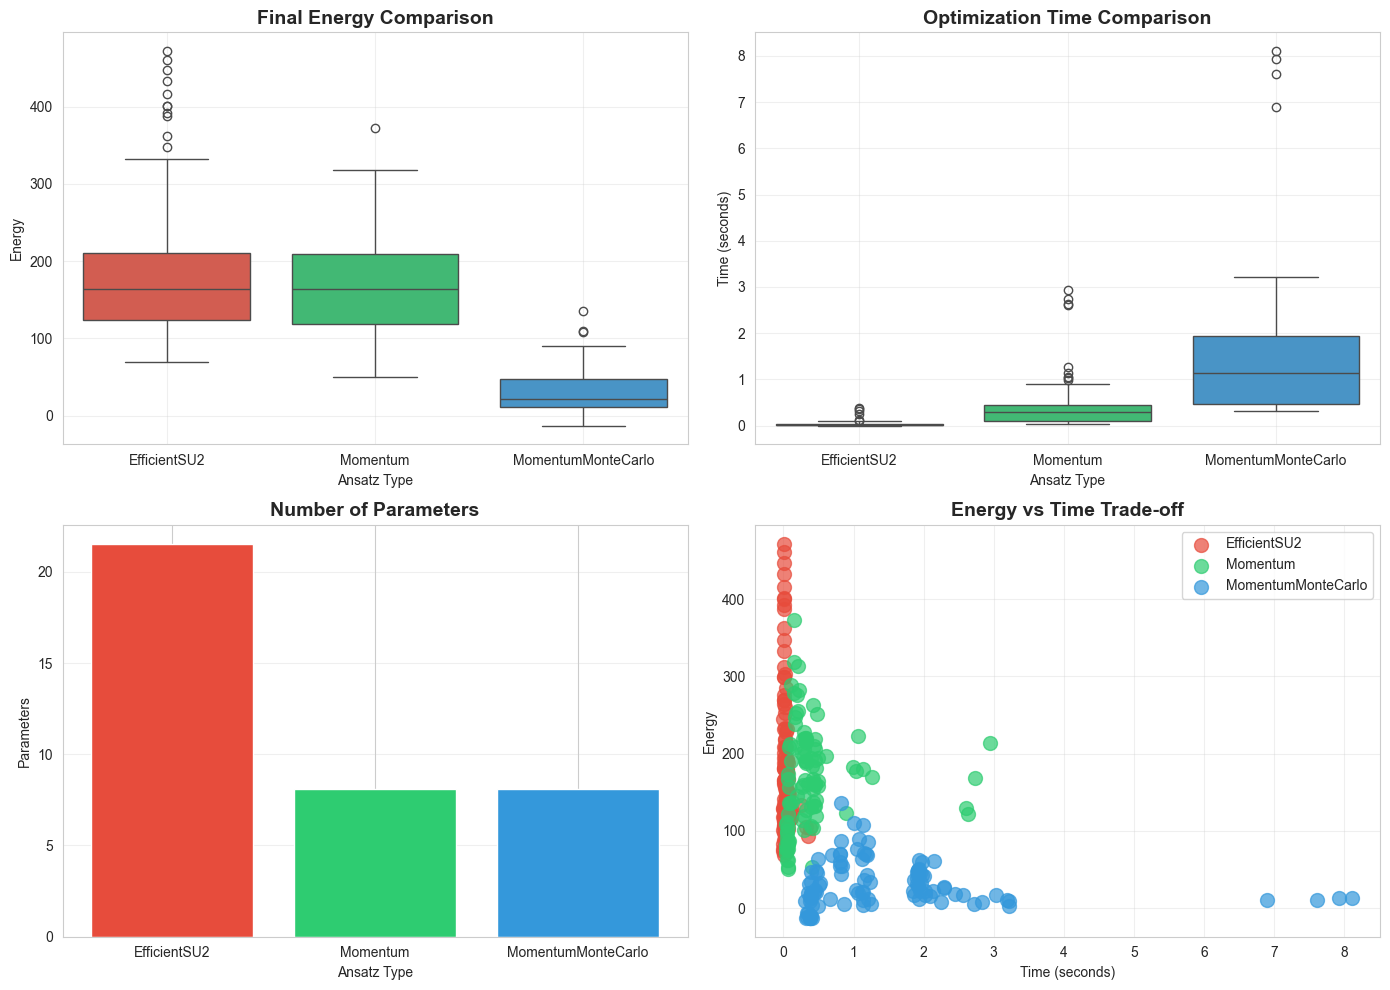

In [12]:
# Visualization 1: Main comparison plots
if len(df) > 0 and "ansatz_type" in df.columns:

    palette = {
        "EfficientSU2": "#e74c3c",
        "Momentum": "#2ecc71",
        "MomentumMonteCarlo": "#3498db"
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ================================
    # 1. Energy Comparison (Boxplot)
    # ================================
    sns.boxplot(
        data=df,
        x="ansatz_type",
        y="energy",
        hue="ansatz_type",
        palette=palette,
        ax=axes[0, 0],
        legend=False
    )

    axes[0, 0].set_title("Final Energy Comparison", fontsize=14, fontweight="bold")
    axes[0, 0].set_xlabel("Ansatz Type")
    axes[0, 0].set_ylabel("Energy")
    axes[0, 0].grid(True, alpha=0.3)


    # ======================================
    # 2. Optimization Time Comparison
    # ======================================
    sns.boxplot(
        data=df,
        x="ansatz_type",
        y="time",
        hue="ansatz_type",
        palette=palette,
        ax=axes[0, 1],
        legend=False
    )

    axes[0, 1].set_title("Optimization Time Comparison", fontsize=14, fontweight="bold")
    axes[0, 1].set_xlabel("Ansatz Type")
    axes[0, 1].set_ylabel("Time (seconds)")
    axes[0, 1].grid(True, alpha=0.3)


    # ======================================
    # 3. Number of Parameters (Bar Plot)
    # ======================================
    param_stats = df.groupby("ansatz_type")["params"].mean()

    axes[1, 0].bar(
        param_stats.index,
        param_stats.values,
        color=[palette[k] for k in param_stats.index]
    )

    axes[1, 0].set_title("Number of Parameters", fontsize=14, fontweight="bold")
    axes[1, 0].set_xlabel("Ansatz Type")
    axes[1, 0].set_ylabel("Parameters")
    axes[1, 0].grid(True, alpha=0.3, axis="y")


    # ======================================
    # 4. Energy vs Time Trade-off (Scatter)
    # ======================================
    for ansatz in df["ansatz_type"].unique():
        subset = df[df["ansatz_type"] == ansatz]
        axes[1, 1].scatter(
            subset["time"],
            subset["energy"],
            label=ansatz,
            alpha=0.7,
            s=100,
            color=palette[ansatz]
        )

    axes[1, 1].set_title("Energy vs Time Trade-off", fontsize=14, fontweight="bold")
    axes[1, 1].set_xlabel("Time (seconds)")
    axes[1, 1].set_ylabel("Energy")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)


    plt.tight_layout()
    plt.savefig("ansatz_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()


Distribution Plots

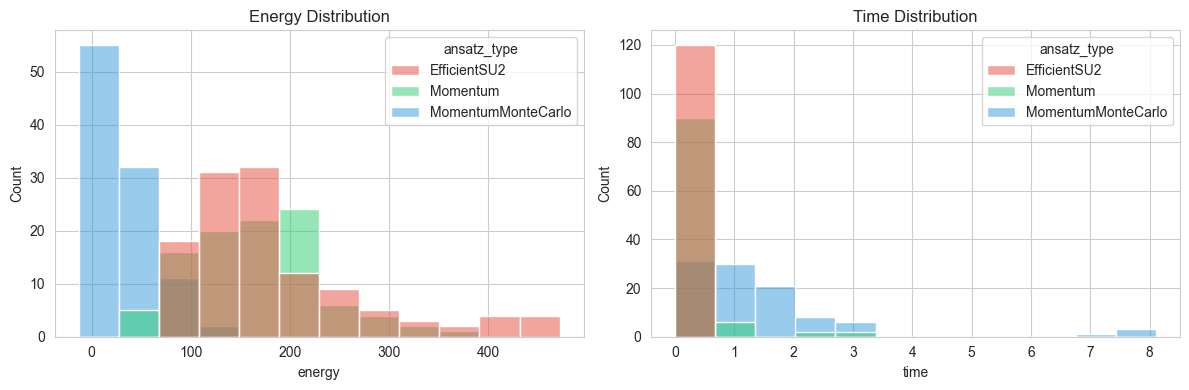

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(data=df, x="energy", hue="ansatz_type",
             palette=palette, bins=12, ax=axes[0])
axes[0].set_title("Energy Distribution")

sns.histplot(data=df, x="time", hue="ansatz_type",
             palette=palette, bins=12, ax=axes[1])
axes[1].set_title("Time Distribution")

plt.tight_layout()
plt.show()


Performance Summary Plot

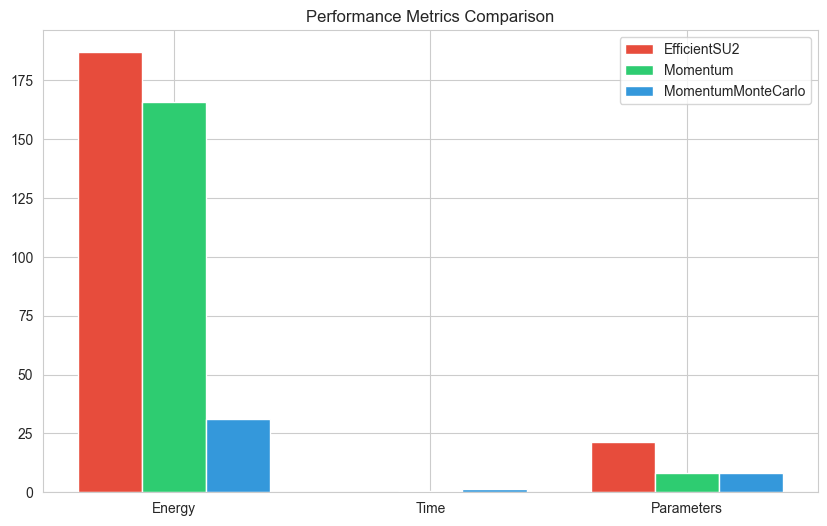

In [14]:
summary_means = df.groupby("ansatz_type").mean()

metrics = ["energy","time","params"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

for i, ansatz in enumerate(summary_means.index):
    ax.bar(x + i*width,
           summary_means.loc[ansatz][metrics],
           width,
           label=ansatz,
           color=palette[ansatz])

ax.set_xticks(x + width)
ax.set_xticklabels(["Energy","Time","Parameters"])
ax.set_title("Performance Metrics Comparison")
ax.legend()

plt.show()


Improvement Metrics for the Momentum Builder

In [17]:
means = df.groupby("ansatz_type").mean()

if "Momentum" in means.index and "EfficientSU2" in means.index:
    e_improve = ((means.loc["EfficientSU2","energy"] - means.loc["Momentum","energy"])
                 / abs(means.loc["EfficientSU2","energy"])) * 100
    t_speedup = means.loc["EfficientSU2","time"] / means.loc["Momentum","time"]
    # p_reduction = ((means.loc["EfficientSU2","params"] - means.loc["Momentum","params"])
                #    / means.loc["EfficientSU2","params"]) * 100

    print("======================================")
    print("PERFORMANCE IMPROVEMENTS")
    print("======================================")
    print(f"MomentumBuilder energy improvement: {e_improve:.2f}%")
    print(f"MomentumBuilder speedup: {t_speedup:.2f}x")
    # print(f"MomentumBuilder parameter reduction: {p_reduction:.2f}%")


PERFORMANCE IMPROVEMENTS
MomentumBuilder energy improvement: 11.27%
MomentumBuilder speedup: 0.09x


Improvement Summary for the Momentum Builder and the Momentum MonteCarlo Builder

In [19]:
means = df.groupby("ansatz_type").mean()

print("======================================")
print("PERFORMANCE IMPROVEMENTS SUMMARY")
print("======================================")

# Ensure all required methods exist
required = ["EfficientSU2", "Momentum", "MomentumMonteCarlo"]

if all(m in means.index for m in required):

    # ==========================
    # Momentum vs EfficientSU2
    # ==========================
    e_improve_m = ((means.loc["EfficientSU2","energy"] - means.loc["Momentum","energy"])
                   / abs(means.loc["EfficientSU2","energy"])) * 100

    t_speedup_m = means.loc["EfficientSU2","time"] / means.loc["Momentum","time"]

    # p_reduction_m = ((means.loc["EfficientSU2","params"] - means.loc["Momentum","params"])
    #                  / means.loc["EfficientSU2","params"]) * 100

    # ======================================
    # MomentumMonteCarlo vs EfficientSU2
    # ======================================
    e_improve_mc = ((means.loc["EfficientSU2","energy"] - means.loc["MomentumMonteCarlo","energy"])
                    / abs(means.loc["EfficientSU2","energy"])) * 100

    t_speedup_mc = means.loc["EfficientSU2","time"] / means.loc["MomentumMonteCarlo","time"]

    # p_reduction_mc = ((means.loc["EfficientSU2","params"] - means.loc["MomentumMonteCarlo","params"])
    #                   / means.loc["EfficientSU2","params"]) * 100

    # ======================================
    # MomentumMonteCarlo vs MomentumBuilder
    # ======================================
    e_improve_mc_vs_m = ((means.loc["Momentum","energy"] - means.loc["MomentumMonteCarlo","energy"])
                         / abs(means.loc["Momentum","energy"])) * 100

    t_ratio_mc_vs_m = means.loc["Momentum","time"] / means.loc["MomentumMonteCarlo","time"]

    # ==========================
    # PRINT RESULTS
    # ==========================

    print("\n--- MomentumBuilder vs EfficientSU2 ---")
    print(f"Energy Improvement:      {e_improve_m:.2f}%")
    print(f"Speedup:                 {t_speedup_m:.2f}x")
    # print(f"Parameter Reduction:     {p_reduction_m:.2f}%")

    print("\n--- MomentumMonteCarlo vs EfficientSU2 ---")
    print(f"Energy Improvement:      {e_improve_mc:.2f}%")
    print(f"Speedup:                 {t_speedup_mc:.2f}x")
    # print(f"Parameter Reduction:     {p_reduction_mc:.2f}%")

    print("\n--- MomentumMonteCarlo vs MomentumBuilder ---")
    print(f"Additional Energy Gain:  {e_improve_mc_vs_m:.2f}%")
    # print(f"Relative Speed Ratio:    {t_ratio_mc_vs_m:.2f}x ( >1 means faster )")

else:
    print("Not all required ansatz types found in results.")


PERFORMANCE IMPROVEMENTS SUMMARY

--- MomentumBuilder vs EfficientSU2 ---
Energy Improvement:      11.27%
Speedup:                 0.09x

--- MomentumMonteCarlo vs EfficientSU2 ---
Energy Improvement:      83.42%
Speedup:                 0.02x

--- MomentumMonteCarlo vs MomentumBuilder ---
Additional Energy Gain:  81.31%
